## Tool-Calling Agent — LLM Decides the Tools in LangGraph


In [1]:
from langchain_core.tools import tool


# --- 1. TOOLS ---
@tool
def add(a: float, b: float) -> float:
    """Add two numbers together."""
    print(f"  ⚙️  add({a}, {b}) → {a+b}")
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    print(f"  ⚙️  multiply({a}, {b}) → {a*b}")
    return a * b


@tool
def get_weather(city: str) -> str:
    """Get current weather for a city."""
    db = {
        "bhopal": "30°C ☀️",
        "mumbai": "28°C 🌫️",
        "delhi": "25°C ⛅",
    }
    r = db.get(city.lower(), f"No data for {city}")
    print(f"  ⚙️  get_weather({city!r}) → {r}")
    return r


tools = [add, multiply, get_weather]

In [2]:
from langchain_core.messages import BaseMessage
from typing import TypedDict, Annotated
import operator


# --- 2. STATE ---
class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]

In [3]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import END

load_dotenv()

# --- 3. NODES ---
# bind_tools() tells the LLM about our tools
llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)


def agent_node(state: State) -> dict:
    print(f"[agent] Thinking... ({len(state['messages'])} msgs in history)")
    return {"messages": [llm.invoke(state["messages"])]}


def should_continue(state: State) -> str:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        print(f"[router] → tools: {[tc['name'] for tc in last.tool_calls]}")
        print(last.tool_calls)
        return "tools"
    print("[router] → END")
    return END

In [4]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

# --- 4. GRAPH ---
tool_node = ToolNode(tools)
builder = StateGraph(State)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
builder.add_edge("tools", "agent")  # ← THE LOOP
graph = builder.compile()

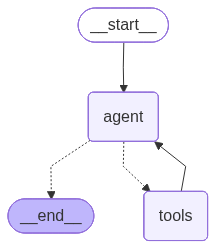

In [5]:
# --- 5. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
from langchain_core.messages import HumanMessage

# --- 6. RUN & TEST ---
for q in [
    "What is (15 + 27) * 3?",
    "Add 15 with 27, then multiply the result with 3",
    # "What's the weather in Bhopal, Delhi and Bengaluru?",
    # "Add 100 and 50, then multiply the result by 4",
]:
    print(f"\n{'='*50}\n❓ {q}")
    print("---")
    result = graph.invoke({"messages": [HumanMessage(q)]})
    print("---")
    print(f"✅ {result['messages'][-1].content}")


❓ What is (15 + 27) * 3?
---
[agent] Thinking... (1 msgs in history)
[router] → tools: ['add', 'multiply']
[{'name': 'add', 'args': {'a': 15, 'b': 27}, 'id': 'call_BWADFtxazxn4LNzAxZ4fqDeb', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a:': 42, 'b': 3}, 'id': 'call_MCg6P5zyrfffMyaW92WxxVao', 'type': 'tool_call'}]
  ⚙️  add(15.0, 27.0) → 42.0
[agent] Thinking... (4 msgs in history)
[router] → tools: ['add', 'multiply']
[{'name': 'add', 'args': {'a': 15, 'b': 27}, 'id': 'call_Yja8tk7HuQq9gY2Tv98JCNwi', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 42, 'b': 3}, 'id': 'call_ZwlAbfzghmghyj4hxCjfpw8k', 'type': 'tool_call'}]
  ⚙️  add(15.0, 27.0) → 42.0
  ⚙️  multiply(42.0, 3.0) → 126.0
[agent] Thinking... (7 msgs in history)
[router] → END
---
✅ The result of \( (15 + 27) \times 3 \) is 126.

❓ Add 15 with 27, then multiply the result with 3
---
[agent] Thinking... (1 msgs in history)
[router] → tools: ['add']
[{'name': 'add', 'args': {'a': 15, 'b': 27}, 'id': 'call_HNcRn